## 1. Setup & Imports

In [1]:

!pip install -q tensorflow scikit-learn seaborn pandas matplotlib pillow opencv-python-headless

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import io, os, time, zipfile, shutil
from datetime import datetime
from PIL import Image

from google.colab import files

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
GPU Available: True


2.Dataset

In [2]:

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 32

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()


x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


val_split = int(0.9 * len(x_train))
x_val, y_val = x_train[val_split:], y_train[val_split:]
x_train, y_train = x_train[:val_split], y_train[:val_split]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2653s 16us/step
Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


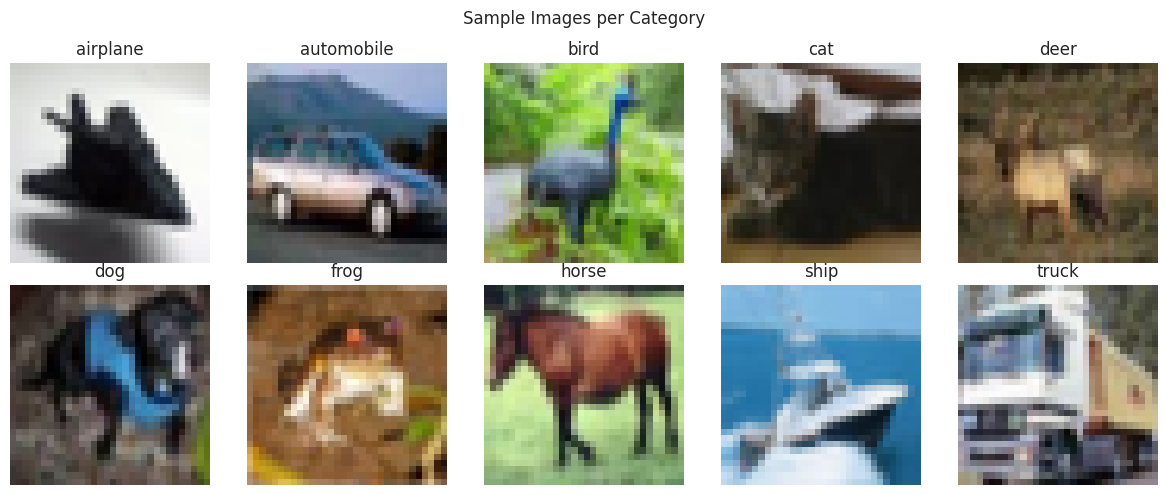

In [3]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(CLASS_NAMES[i])
    ax.axis('off')
plt.suptitle("Sample Images per Category")
plt.tight_layout()
plt.show()


## 3. CNN Model Architecture

In [5]:
def build_cnn_model(input_shape=(32, 32, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn_model()
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,458 (2.55 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

## 4. Training

In [6]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

augmented_train = tf.data.Dataset.from_tensor_slices((x_train, y_train)) \
    .shuffle(2000) \
    .batch(64) \
    .map(lambda x, y: (data_augmentation(x, training=True), y)) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(64)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ModelCheckpoint('best_cnn_model.keras', save_best_only=True, monitor='val_accuracy')
]

EPOCHS = 20

history = cnn_model.fit(
    augmented_train,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.3920 - loss: 1.7943 - val_accuracy: 0.4546 - val_loss: 1.5730
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5369 - loss: 1.2958 - val_accuracy: 0.5198 - val_loss: 1.4100
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5936 - loss: 1.1395 - val_accuracy: 0.6456 - val_loss: 1.0206
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6331 - loss: 1.0435 - val_accuracy: 0.5346 - val_loss: 1.4219
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6546 - loss: 0.9776 - val_accuracy: 0.7102 - val_loss: 0.8355
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6710 - loss: 0.9353 - val_accuracy: 0.7026 - val_loss: 0.9329
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6918 - loss: 0.8793 - val_accuracy: 0.7112 - val_loss: 0.8544
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7048 - loss: 0.8455 - 

## 5. Model Evaluation

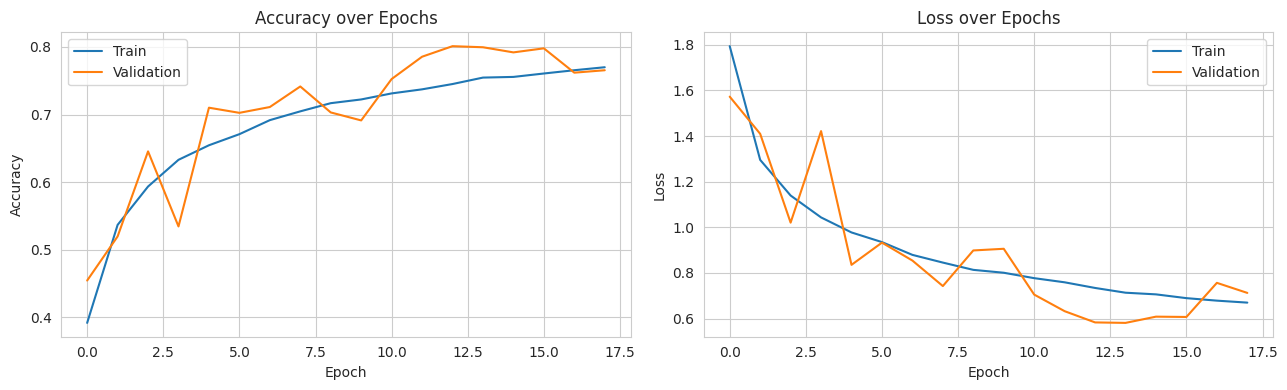

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()


Test Accuracy: 0.7900
Test Loss:     0.6206


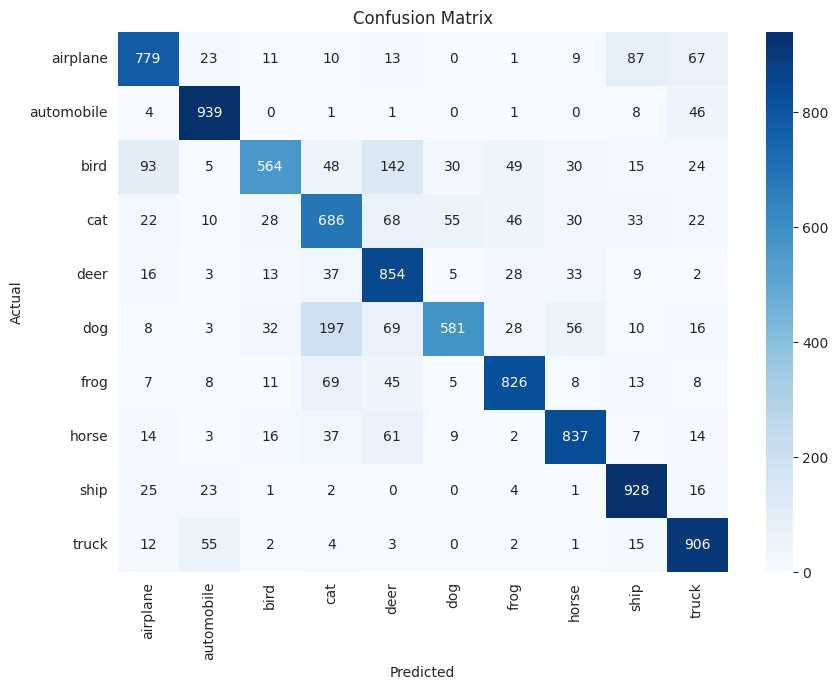

              precision    recall  f1-score   support

    airplane       0.79      0.78      0.79      1000
  automobile       0.88      0.94      0.91      1000
        bird       0.83      0.56      0.67      1000
         cat       0.63      0.69      0.66      1000
        deer       0.68      0.85      0.76      1000
         dog       0.85      0.58      0.69      1000
        frog       0.84      0.83      0.83      1000
       horse       0.83      0.84      0.83      1000
        ship       0.82      0.93      0.87      1000
       truck       0.81      0.91      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000



In [8]:

test_loss, test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

y_pred_probs = cnn_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


In [9]:

cnn_model.save('image_classifier.keras')
print("Model saved as image_classifier.keras")


Model saved as image_classifier.keras


6.Feature Image Upload

In [10]:
def upload_image():
    """Opens a file picker in Colab and returns (PIL.Image, filename)."""
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    return img, filename


## 7. Feature: Image Classification & Prediction Confidence

In [11]:
def preprocess_image(img, target_size=(IMG_SIZE, IMG_SIZE)):
    img_resized = img.resize(target_size)
    arr = np.array(img_resized).astype('float32') / 255.0
    return np.expand_dims(arr, axis=0)

def classify_image(model, img, class_names=CLASS_NAMES):
    """Returns predicted class, confidence (%), and full probability vector."""
    batch = preprocess_image(img)
    probs = model.predict(batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], float(probs[pred_idx]) * 100, probs


## 8. Feature: Result Dashboard

In [12]:
def display_results(img, predicted_class, confidence, probs, class_names=CLASS_NAMES, top_k=5):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")

    top_idx = np.argsort(probs)[::-1][:top_k]
    top_classes = [class_names[i] for i in top_idx]
    top_probs = probs[top_idx] * 100

    colors = ['#4C72B0' if c != predicted_class else '#DD8452' for c in top_classes]
    axes[1].barh(top_classes[::-1], top_probs[::-1], color=colors[::-1])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f'Top {top_k} Predictions')

    plt.tight_layout()
    plt.show()


9.Feature

In [13]:
prediction_history = pd.DataFrame(columns=['timestamp', 'filename', 'model', 'predicted_class', 'confidence_%'])

def log_prediction(filename, predicted_class, confidence, model_name='Custom CNN'):
    global prediction_history
    new_row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'filename': filename,
        'model': model_name,
        'predicted_class': predicted_class,
        'confidence_%': round(confidence, 2)
    }
    prediction_history = pd.concat([prediction_history, pd.DataFrame([new_row])], ignore_index=True)

def show_history():
    if prediction_history.empty:
        print("No predictions logged yet.")
        return
    display(prediction_history)

    plt.figure(figsize=(8, 4))
    prediction_history['predicted_class'].value_counts().plot(kind='bar', color='#4C72B0')
    plt.title('Predictions per Category (This Session)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


10.Full Pipeline

In [14]:
def classify_uploaded_image(model=cnn_model, model_name='Custom CNN'):
    img, filename = upload_image()
    predicted_class, confidence, probs = classify_image(model, img)
    display_results(img, predicted_class, confidence, probs)
    log_prediction(filename, predicted_class, confidence, model_name)
    print(f"Logged: {filename} -> {predicted_class} ({confidence:.2f}%)")
    return img, predicted_class, confidence, probs


Saving Gemini_Generated_Image_5aw7m15aw7m15aw7.png to Gemini_Generated_Image_5aw7m15aw7m15aw7.png


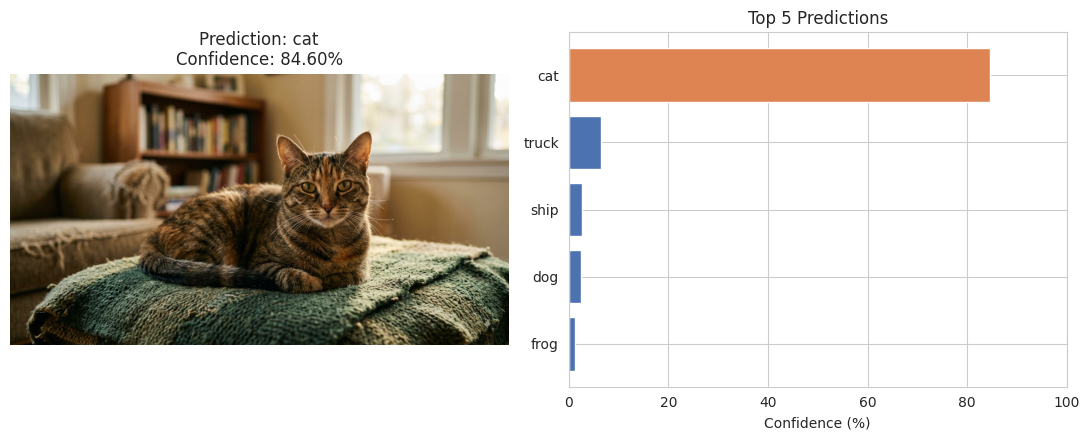

Logged: Gemini_Generated_Image_5aw7m15aw7m15aw7.png -> cat (84.60%)


/tmp/ipykernel_515/989448783.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prediction_history = pd.concat([prediction_history, pd.DataFrame([new_row])], ignore_index=True)


(<PIL.Image.Image image mode=RGB size=1408x768>,
 'cat',
 84.5995843410492,
 array([0.00382404, 0.0085824 , 0.00187148, 0.84599584, 0.00464733,
        0.0246222 , 0.01305929, 0.00628903, 0.02663375, 0.06447475],
       dtype=float32))

In [15]:

classify_uploaded_image()


,timestamp,filename,model,predicted_class,confidence_%
0,2026-08-13 13:08:20,Gemini_Generated_Image_5aw7m15aw7m15aw7.png,Custom CNN,cat,84.6


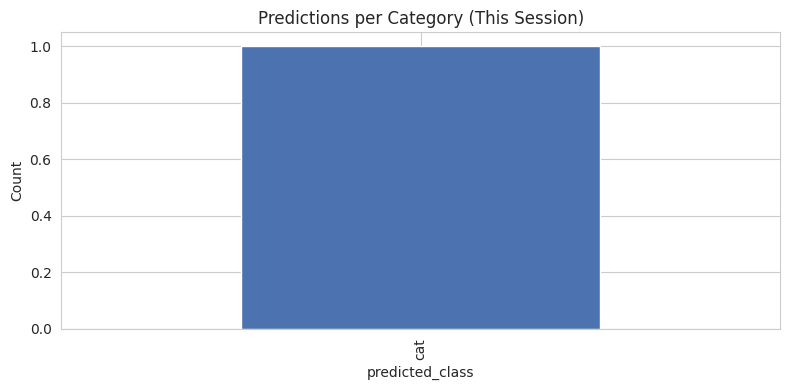

In [16]:

show_history()


In [17]:
def upload_and_extract_dataset(extract_dir='custom_dataset'):
    print("Upload a .zip file containing one folder per class.")
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]

    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
    os.makedirs(extract_dir)

    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(extract_dir)


    contents = [c for c in os.listdir(extract_dir) if not c.startswith('__MACOSX')]
    if len(contents) == 1 and os.path.isdir(os.path.join(extract_dir, contents[0])):
        extract_dir = os.path.join(extract_dir, contents[0])

    classes = sorted([c for c in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, c))])
    print(f"Found {len(classes)} classes: {classes}")
    return extract_dir, classes


def build_transfer_model(num_classes, img_size=(160, 160)):
    base = keras.applications.MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
    base.trainable = False
    model = models.Sequential([
        layers.Input(shape=img_size + (3,)),
        layers.Rescaling(1.0),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def train_on_custom_dataset(data_dir, img_size=(160, 160), batch_size=16, epochs=10):
    train_ds = keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset='training', seed=42,
        image_size=img_size, batch_size=batch_size)
    val_ds = keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset='validation', seed=42,
        image_size=img_size, batch_size=batch_size)

    class_names_custom = train_ds.class_names

    preprocess = keras.applications.mobilenet_v2.preprocess_input
    train_ds = train_ds.map(lambda x, y: (preprocess(x), y)).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (preprocess(x), y)).prefetch(tf.data.AUTOTUNE)

    model = build_transfer_model(len(class_names_custom), img_size)
    history_custom = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

    return model, class_names_custom, history_custom



## Upgrade 2: Real-Time Camera Detection

Captures a snapshot from your webcam (browser permission required) and classifies it instantly.

In [18]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='camera_capture.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


def classify_from_camera(model=cnn_model, model_name='Custom CNN'):
    filename = take_photo()
    img = Image.open(filename).convert('RGB')
    predicted_class, confidence, probs = classify_image(model, img)
    display_results(img, predicted_class, confidence, probs)
    log_prediction(filename, predicted_class, confidence, model_name)
    return img, predicted_class, confidence, probs



## Upgrade 3: Multiple Model Comparison

Compares the custom CNN against transfer-learning models (MobileNetV2, ResNet50) on accuracy, inference speed, and model size.

In [19]:
def build_pretrained_classifier(base_name='MobileNetV2', img_size=(96, 96), num_classes=NUM_CLASSES):
    base_ctor = {
        'MobileNetV2': keras.applications.MobileNetV2,
        'ResNet50': keras.applications.ResNet50,
    }[base_name]

    base = base_ctor(input_shape=img_size + (3,), include_top=False, weights='imagenet')
    base.trainable = False

    model = models.Sequential([
        layers.Input(shape=img_size + (3,)),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def prep_for_pretrained(images, img_size=(96, 96)):
    resized = tf.image.resize(images, img_size)
    return resized


def compare_models(models_dict, x_eval, y_eval, sample_size=1000):
    """models_dict: {'name': (model, expects_resize_bool)}"""
    idx = np.random.choice(len(x_eval), size=min(sample_size, len(x_eval)), replace=False)
    xs, ys = x_eval[idx], y_eval[idx]

    results = []
    for name, model in models_dict.items():
        start = time.time()
        preds = model.predict(xs, verbose=0)
        elapsed = time.time() - start

        acc = (np.argmax(preds, axis=1) == ys).mean()
        n_params = model.count_params()

        results.append({
            'Model': name,
            'Accuracy': round(float(acc), 4),
            'Avg Inference Time (ms/img)': round((elapsed / len(xs)) * 1000, 3),
            'Parameters': f"{n_params:,}"
        })

    df = pd.DataFrame(results)
    display(df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(df['Model'], df['Accuracy'], color='#55A868')
    axes[0].set_title('Accuracy Comparison'); axes[0].set_ylabel('Accuracy')

    axes[1].bar(df['Model'], df['Avg Inference Time (ms/img)'], color='#C44E52')
    axes[1].set_title('Inference Speed Comparison'); axes[1].set_ylabel('ms / image')

    plt.tight_layout()
    plt.show()
    return df

